<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Arturo Amberg
- Nombre de alumno 2: Juan Muñoz

### **Link de repositorio de GitHub:** [Nuestro Repositorio](https://github.com/jp835/Repositorio-laboratorio-de-programaci-n-cient-fica-grupo-LosTcg.git)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Miercoles a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [42]:
# Librerias
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [43]:
# Cargar datos
df = pd.read_csv("energia_homero.csv")

# Transformar columna date a datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Visualización del consumo energético
fig = px.line(
    df,
    x='date',
    y='Energy_kWh',
    title='Consumo diario de energía (2016–2020)',
    labels={'date': 'Fecha', 'Energy_kWh': 'Consumo (kWh)'}
)
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Consumo de Energía (kWh)',
    template='plotly_white'
)
fig.show()

## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

3. Se pueden ver incrementos de consumo en los periodos de invernos, si se analiza los gráficos se puede ver un claro aumento en ciertos periodos del año.

In [44]:
# 0 División train/test 
fecha_limite = pd.to_datetime("2020-02-29")
train_df = df[df['date'] <= fecha_limite].copy()
test_df  = df[df['date'] >= pd.to_datetime("2020-03-01")].copy()

print(f"Filas train: {len(train_df)}, filas test: {len(test_df)}")

date0 = df['date'].min()

def make_time_feature(dates):
    # Convierte fechas a número de días desde date0     
    delta = (pd.to_datetime(dates) - pd.to_datetime(date0))
    days = delta.dt.total_seconds() / (3600 * 24)          
    return days.values.reshape(-1, 1)

# Transformaciones para sklearn pipeline
time_transformer = FunctionTransformer(make_time_feature, validate=False)


Filas train: 1369, filas test: 129


In [45]:
# 1 Pipeline de regresión lineal
Pipeline_trend = Pipeline([
    ("time", time_transformer),
    ("scaler", StandardScaler()),   
    ("lr", LinearRegression())
])

X_train_time = train_df['date']
y_train = train_df['Energy_kWh'].values

X_test_time = test_df['date']
y_test = test_df['Energy_kWh'].values

# Entrenar
Pipeline_trend.fit(X_train_time, y_train)

# Predicciones (entrenamiento y test)
y_train_pred_trend = Pipeline_trend.predict(train_df['date'])
y_test_pred_trend  = Pipeline_trend.predict(test_df['date'])

# También predecir para todo el rango (para graficar serie completa)
y_full_pred_trend = Pipeline_trend.predict(df['date'])

In [46]:
# 2 Evaluar desempeño
mae_train_trend = mean_absolute_error(y_train, y_train_pred_trend)
mae_test_trend  = mean_absolute_error(y_test, y_test_pred_trend)

print("=== TREND (Linear) ===")
print(f"MAE train: {mae_train_trend:.4f}")
print(f"MAE test : {mae_test_trend:.4f}")

# Graficar serie real vs predicción de tendencia
fig_trend = go.Figure()
fig_trend.add_trace(go.Scatter(x=df['date'], y=df['Energy_kWh'],
                               mode='lines', name='Real', line=dict(width=1)))
fig_trend.add_trace(go.Scatter(x=df['date'], y=y_full_pred_trend,
                               mode='lines', name='Trend_pred', line=dict(width=2)))
fig_trend.update_layout(title="Real vs Predicción de Tendencia (Linear)",
                        xaxis_title="Fecha", yaxis_title="Energy (kWh)",
                        template='plotly_white')
fig_trend.show()

=== TREND (Linear) ===
MAE train: 10.5682
MAE test : 8.6558


In [47]:
# 3 Graficar residuales
residuals_trend = df['Energy_kWh'].values - y_full_pred_trend

fig_res_trend = px.line(x=df['date'], y=residuals_trend,
                        labels={'x':'date', 'y':'Error (Real - Predicho)'},
                        title='Error (Real - Predicho) — Trend model (completo)')
fig_res_trend.update_layout(template='plotly_white')
fig_res_trend.show()

In [48]:
# 4 Pipeline con características de Fourier para estacionalidad
def fourier_features(dates, period=365.25, n_terms=3):
    """
    dates: pandas Series or array-like of datetime
    retorna matriz (len(dates), 2*n_terms) con columnas:
    [sin(2π t / P), cos(2π t / P), sin(2π *2 t / P), cos(2π *2 t / P), ...]
    t será días desde date0 (float)
    """
    t_days = make_time_feature(pd.to_datetime(dates)).flatten()  # vector días
    X = []
    for k in range(1, n_terms + 1):
        ang = 2 * np.pi * k * t_days / period
        X.append(np.sin(ang))
        X.append(np.cos(ang))
    X = np.vstack(X).T  # shape (n_samples, 2*n_terms)
    return X

# Wrapper para usar en FunctionTransformer
def fourier_transformer_factory(period=365.25, n_terms=3):
    return FunctionTransformer(lambda dates: fourier_features(dates, period=period, n_terms=n_terms),
                               validate=False)

# Valores elegidos:
P = 365.25   # periodo anual
n = 3        

Pipeline_seasonal = Pipeline([
    ("fourier", fourier_transformer_factory(period=P, n_terms=n)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

In [49]:
# 5 Pipeline con Fourier
# Residuales de train respecto a tendencia
train_trend_pred = Pipeline_trend.predict(train_df['date'])
train_resid = train_df['Energy_kWh'].values - train_trend_pred

# Entrenar Pipeline_seasonal sobre train dates -> train_resid
Pipeline_seasonal.fit(train_df['date'], train_resid)

# Predecir estacionalidad para train, test y todo el df
season_train_pred = Pipeline_seasonal.predict(train_df['date'])
season_test_pred  = Pipeline_seasonal.predict(test_df['date'])
season_full_pred  = Pipeline_seasonal.predict(df['date'])

# Reconstrucción: trend_pred + seasonal_pred
# Para entrenamiento
recon_train = train_trend_pred + season_train_pred
# Para test
recon_test = Pipeline_trend.predict(test_df['date']) + season_test_pred
# Para toda la serie
recon_full = y_full_pred_trend + season_full_pred

# MAE
mae_train_seasonal = mean_absolute_error(y_train, recon_train)
mae_test_seasonal  = mean_absolute_error(y_test, recon_test)

print("\n=== TREND + SEASONAL (Fourier n=3, P=365.25) ===")
print(f"MAE train: {mae_train_seasonal:.4f}")
print(f"MAE test : {mae_test_seasonal:.4f}")

# Graficar reconstrucción vs real
fig_season = go.Figure()
fig_season.add_trace(go.Scatter(x=df['date'], y=df['Energy_kWh'],
                                mode='lines', name='Real', line=dict(width=1)))
fig_season.add_trace(go.Scatter(x=df['date'], y=recon_full,
                                mode='lines', name='Trend+Seasonal_pred', line=dict(width=2)))
fig_season.update_layout(title=f"Real vs Predicción (Trend + Seasonal) — P={P}, n={n}",
                         xaxis_title="Fecha", yaxis_title="Energy (kWh)",
                         template='plotly_white')
fig_season.show()


=== TREND + SEASONAL (Fourier n=3, P=365.25) ===
MAE train: 5.6230
MAE test : 6.0470


In [50]:
residuals_combined = df['Energy_kWh'].values - recon_full

fig_res_comb = px.line(x=df['date'], y=residuals_combined,
                      labels={'x':'date', 'y':'Error (Real - Predicho)'},
                      title=f'Error (Real - Predicho) — Trend + Seasonal (P={P}, n={n})')
fig_res_comb.update_layout(template='plotly_white')
fig_res_comb.show()

# Calcular MAE por conjunto (ya calculado) y mostrarlos juntos
print("\nResumen de MAE:")
print(f"Trend only - MAE train: {mae_train_trend:.4f}, MAE test: {mae_test_trend:.4f}")
print(f"Trend+Season - MAE train: {mae_train_seasonal:.4f}, MAE test: {mae_test_seasonal:.4f}")

# Adicional: gráfico de errores por periodo (ej. boxplot por mes) para ver estacionalidad
df_err = df.copy()
df_err['resid_trend'] = df['Energy_kWh'].values - y_full_pred_trend
df_err['resid_comb']  = df['Energy_kWh'].values - recon_full
df_err['month'] = df_err['date'].dt.month

fig_box = px.box(df_err, x='month', y='resid_comb',
                 labels={'month':'Mes', 'resid_comb':'Error (Real - Predicho)'},
                 title='Distribución del error por mes (modelo Trend+Seasonal)')
fig_box.update_layout(template='plotly_white')
fig_box.show()


Resumen de MAE:
Trend only - MAE train: 10.5682, MAE test: 8.6558
Trend+Season - MAE train: 5.6230, MAE test: 6.0470


## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

**Respuesta:**

Si se pueden ver comportamientos estacionales en la serie son visibles en los fin de semana y en los meses de julio y junio

In [51]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

In [52]:
# 1 Preparar datos para Prophet
train_prophet = train_df.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test_prophet  = test_df.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

In [53]:
# 2 Crear y entrenar modelo Prophet
model = Prophet(
    yearly_seasonality=True,    # patrones anuales (verano/invierno)
    weekly_seasonality=True,    # patrones semanales
    daily_seasonality=False     # no es necesario para consumo diario
)

model.fit(train_prophet)

# Crear DataFrame futuro (entrenamiento + prueba)
future = pd.concat([train_prophet[['ds']], test_prophet[['ds']]], axis=0)

# Realizar predicciones
forecast = model.predict(future)

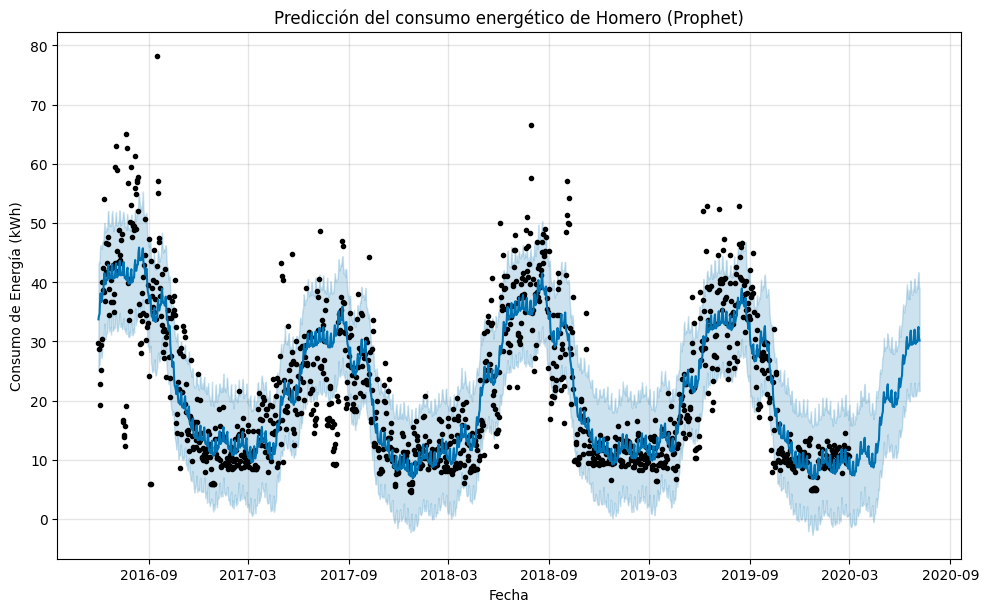

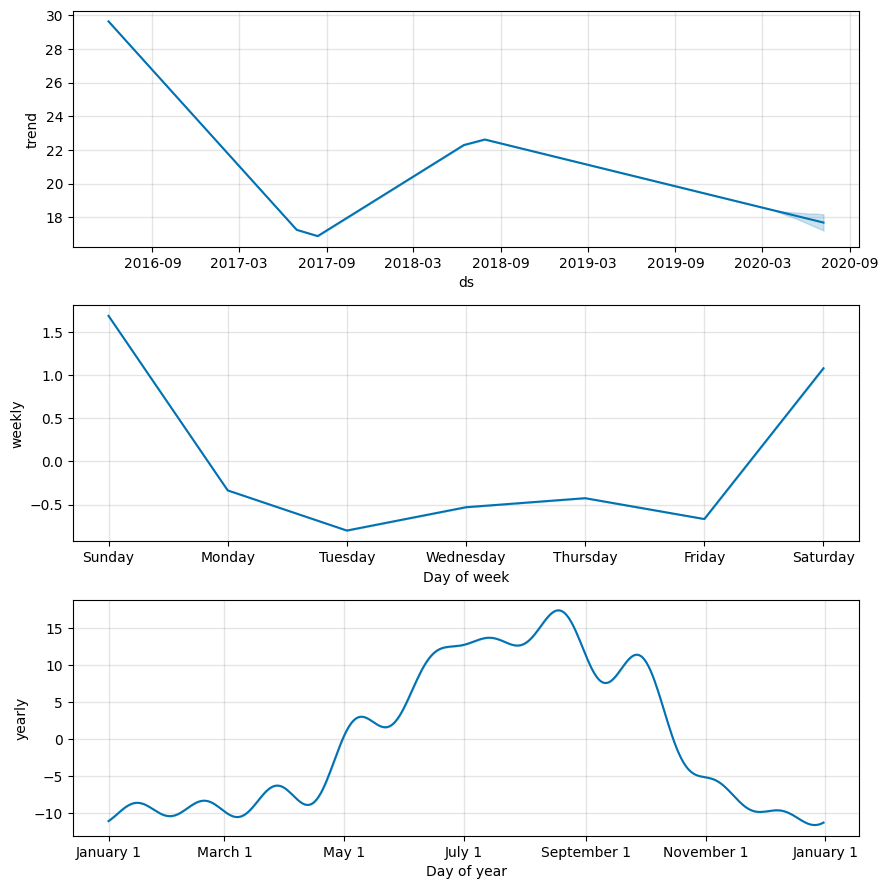

In [54]:
# 3 Predicción total
fig1 = model.plot(forecast)
plt.title("Predicción del consumo energético de Homero (Prophet)")
plt.xlabel("Fecha")
plt.ylabel("Consumo de Energía (kWh)")
plt.show()

# Componentes del modelo
fig2 = model.plot_components(forecast)
plt.show()

In [55]:
# 4 Unir predicciones con los valores reales
results = forecast[['ds', 'yhat']].merge(df, left_on='ds', right_on='date')

# Separar en train y test
train_pred = results[results['date'] <= fecha_limite]
test_pred  = results[results['date'] >= pd.to_datetime("2020-03-01")]

# Calcular MAE
mae_train = mean_absolute_error(train_pred['Energy_kWh'], train_pred['yhat'])
mae_test  = mean_absolute_error(test_pred['Energy_kWh'], test_pred['yhat'])

print(f"MAE Entrenamiento: {mae_train:.2f}")
print(f"MAE Prueba: {mae_test:.2f}")

MAE Entrenamiento: 4.82
MAE Prueba: 4.93


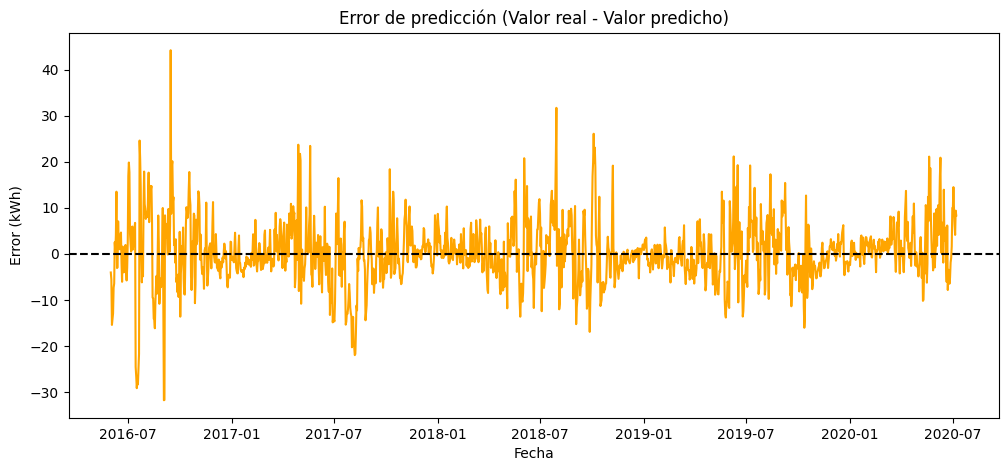

In [56]:
# 5 Graficar errores
results['error'] = results['Energy_kWh'] - results['yhat']

plt.figure(figsize=(12, 5))
plt.plot(results['date'], results['error'], color='orange')
plt.axhline(0, color='black', linestyle='--')
plt.title("Error de predicción (Valor real - Valor predicho)")
plt.xlabel("Fecha")
plt.ylabel("Error (kWh)")
plt.show()

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

3. Si afectan en los resultados, se puede ver una reducción en el MAE, aun que no es tan siginificativo, con solo una reducción a 4.54 de 4.93.
4. Si se ven los mismos comportamientos estacionales que la pregunta anterior, estas son entorno al fin de semana y los meses de invierno, es decir Junio, Julio y Agosto

In [57]:
from prophet import Prophet

In [58]:
# 0 Cargar datos
df = pd.read_csv("energia_homero.csv")
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Datos climáticos de Frink
clima = pd.read_csv("datos_frink.csv")
clima['date'] = pd.to_datetime(clima['date'], format='%Y-%m-%d')

df_merged = pd.merge(df, clima, on='date', how='left')

fecha_limite = pd.to_datetime("2020-02-29")
train_df = df_merged[df_merged['date'] <= fecha_limite].copy()
test_df  = df_merged[df_merged['date'] >= pd.to_datetime("2020-03-01")].copy()

In [ ]:
# 1 Variables exógenas
regresores = [
    'Temp_avg', 'Hum_avg', 'Wind_avg', 'Press_avg'
]  # Puedes ajustar esta lista

# Prophet requiere columnas específicas
train_prophet = train_df.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test_prophet  = test_df.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})


In [60]:
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Agregar regresores al modelo
for reg in regresores:
    m.add_regressor(reg)

# Entrenar modelo
m.fit(train_prophet[['ds', 'y'] + regresores])

In [61]:
future = pd.concat([train_prophet, test_prophet], axis=0)
forecast = m.predict(future[['ds'] + regresores])

# Unir con datos reales
results = future.copy()
results['yhat'] = forecast['yhat']

In [62]:
mae_train = mean_absolute_error(
    results.loc[results['ds'] <= fecha_limite, 'y'],
    results.loc[results['ds'] <= fecha_limite, 'yhat']
)

mae_test = mean_absolute_error(
    results.loc[results['ds'] >= pd.to_datetime("2020-03-01"), 'y'],
    results.loc[results['ds'] >= pd.to_datetime("2020-03-01"), 'yhat']
)

print(f"MAE Train: {mae_train:.2f}")
print(f"MAE Test : {mae_test:.2f}")

MAE Train: 4.74
MAE Test : 4.54


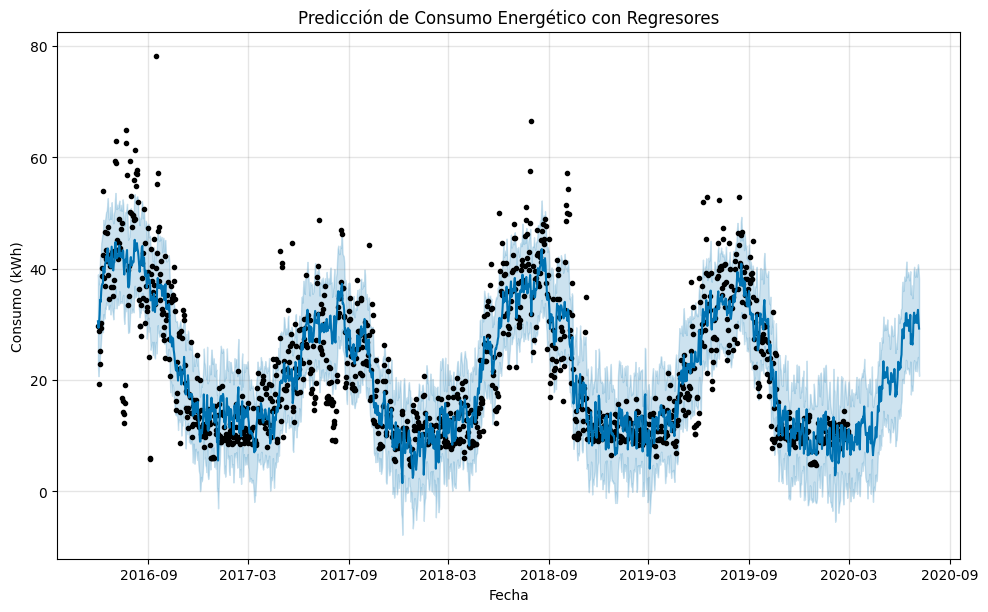

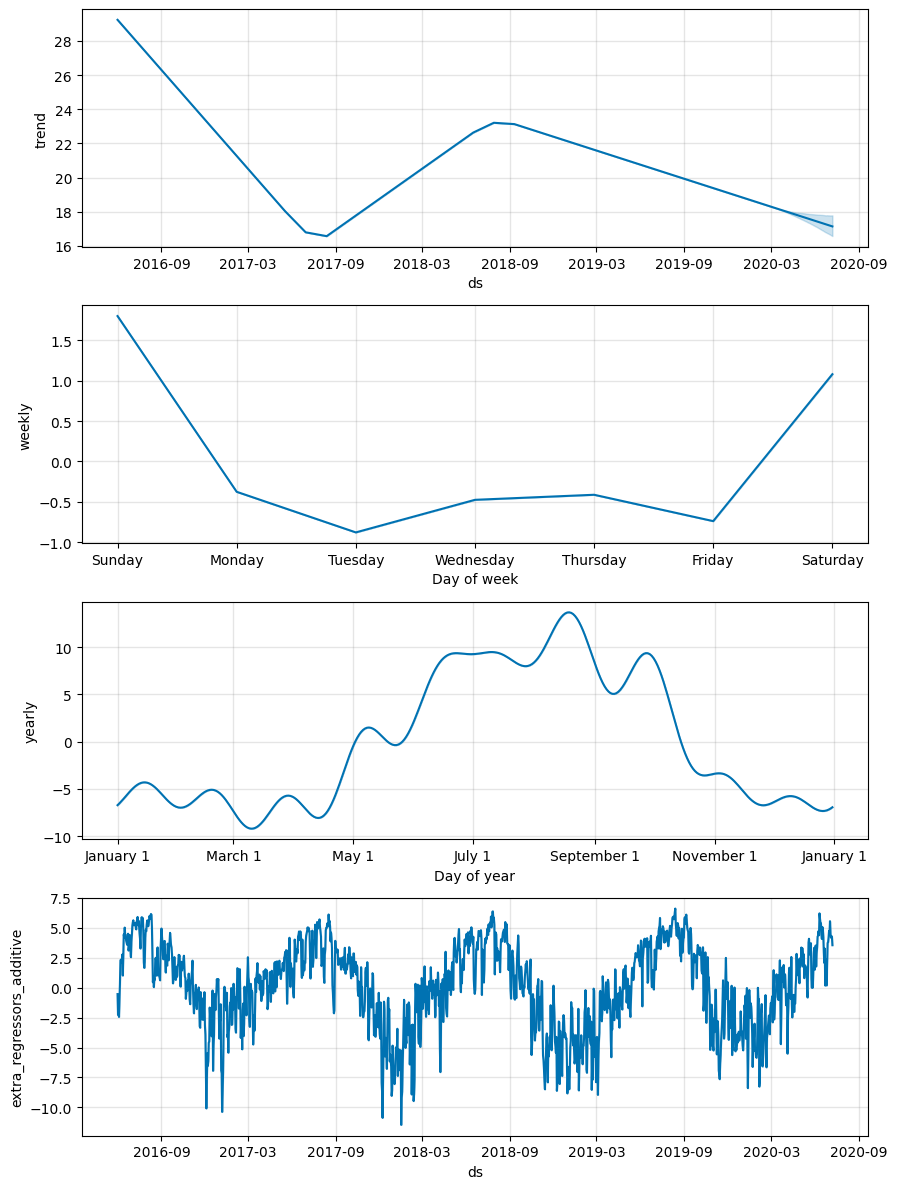

In [63]:
# 2 Gráfico general
fig1 = m.plot(forecast)
plt.title("Predicción de Consumo Energético con Regresores")
plt.xlabel("Fecha")
plt.ylabel("Consumo (kWh)")
plt.show()

# Componentes del modelo
fig2 = m.plot_components(forecast)
plt.show()

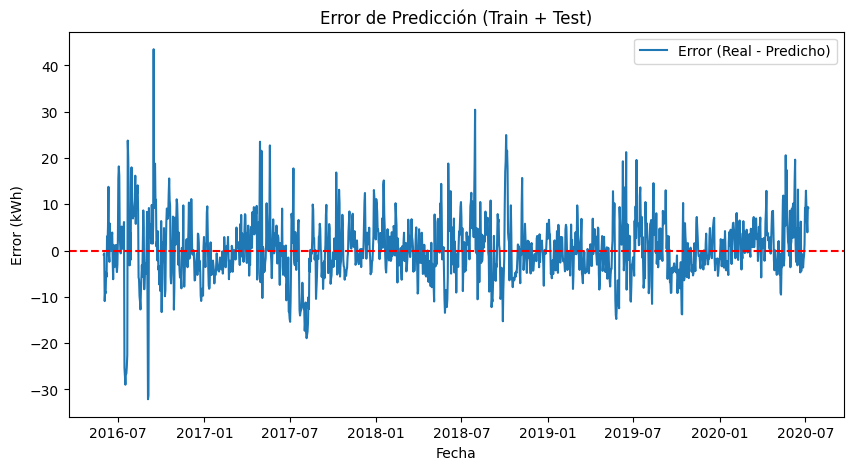

In [64]:
# 4 Graficar errores
results['error'] = results['y'] - results['yhat']

plt.figure(figsize=(10,5))
plt.plot(results['ds'], results['error'], label='Error (Real - Predicho)')
plt.axhline(0, color='red', linestyle='--')
plt.title("Error de Predicción (Train + Test)")
plt.xlabel("Fecha")
plt.ylabel("Error (kWh)")
plt.legend()
plt.show()

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

Se puede ver que a nivel semanal es capaz de predecir mejor los aumentos en luz y de la misma manera en periodos de invierno, es decir en junio y julio. Pero cabe recalcar que no es tan significativo,, haciendo la reducción del mae, muy pequeño con la pregunta anterior.

En un ambito general, la inclusion de lags ayuda al modelo predecir mejor las variables estacionarias

In [65]:
from statsmodels.graphics.tsaplots import plot_pacf, pacf


In [66]:
regresores = ['Temp_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']


<Figure size 600x300 with 0 Axes>

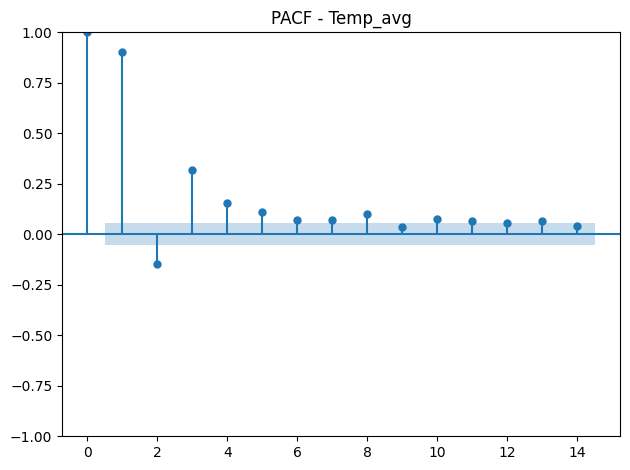

<Figure size 600x300 with 0 Axes>

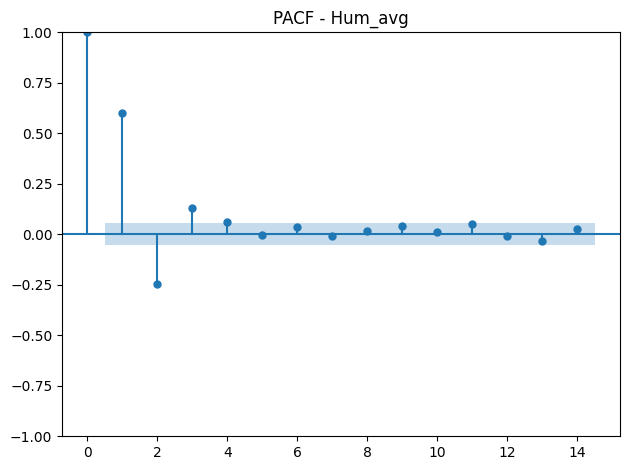

<Figure size 600x300 with 0 Axes>

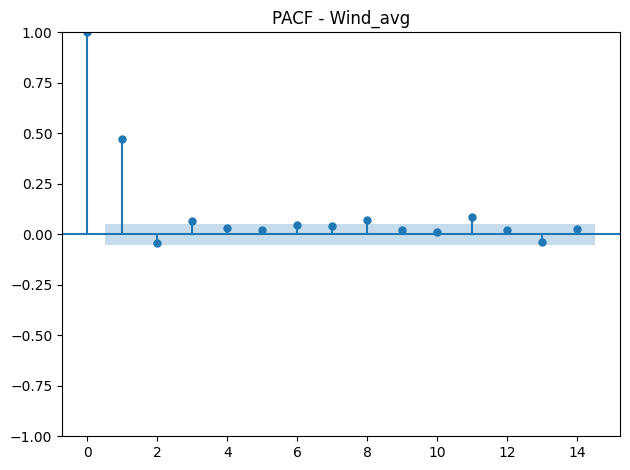

<Figure size 600x300 with 0 Axes>

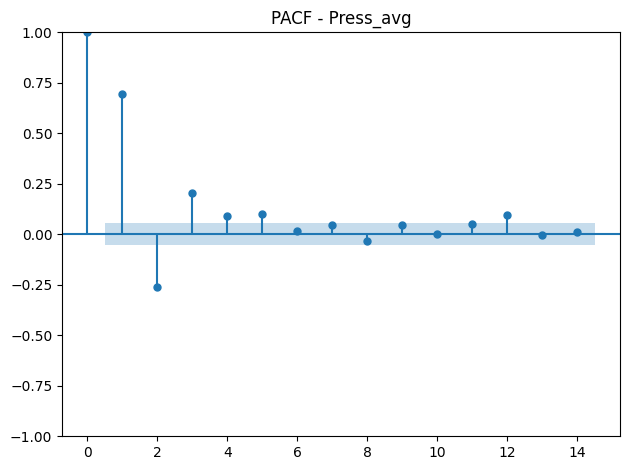

In [ ]:
train = df_merged[df_merged['date'] <= fecha_limite].copy()

max_lags = 14  
pacf_dict = {}
plt.rcParams.update({'figure.max_open_warning': 0})

for var in regresores:
    series = train[var].dropna()
    plt.figure(figsize=(6,3))
    plot_pacf(series, lags=max_lags, method='ywm', title=f'PACF - {var}')
    plt.tight_layout()
    plt.show()

    # Método actualizado compatible
    pacf_vals = pacf(series, nlags=max_lags, method='yw')
    pacf_dict[var] = pacf_vals

In [68]:
lags_dict = {}
threshold = 0.20
for var, vals in pacf_dict.items():
    # vals[0] es lag0 (autocorr 1), ignorar
    chosen = [i for i, v in enumerate(vals) if i>0 and abs(v) > threshold]
    # limitar a primeros 3 lags para evitar demasiados regresores
    chosen = chosen[:3]
    if len(chosen)==0:
        # si no hay lags significativos, tomar lag 1 por si efecto débil
        chosen = [1]
    lags_dict[var] = chosen

print("Lags seleccionados proposed (heurística |PACF|>0.20):")
for k,v in lags_dict.items():
    print(f"  {k}: {v}")

Lags seleccionados proposed (heurística |PACF|>0.20):
  Temp_avg: [1, 3]
  Hum_avg: [1, 2]
  Wind_avg: [1]
  Press_avg: [1, 2, 3]


In [69]:
for var, lags in lags_dict.items():
    for lag in lags:
        colname = f"{var}_lag{lag}"
        df_merged[colname] = df_merged[var].shift(lag)

In [70]:
lag_cols = [c for c in df_merged.columns if c.endswith(tuple([f"_lag{l}" for v in lags_dict for l in lags_dict[v]]))]
# Construir list
lag_cols = []
for var, lags in lags_dict.items():
    for lag in lags:
        lag_cols.append(f"{var}_lag{lag}")

for col in lag_cols:
    mean_val = df_merged[col].mean()
    df_merged[col].fillna(mean_val, inplace=True)


C:\Users\admin\AppData\Local\Temp\ipykernel_18000\4001529818.py:10: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [71]:
train_df = df_merged[df_merged['date'] <= fecha_limite].copy()
test_df  = df_merged[df_merged['date'] >= pd.to_datetime("2020-03-01")].copy()

# Preparar para Prophet: renombrar ds,y
train_prophet = train_df.rename(columns={'date':'ds', 'Energy_kWh':'y'})
test_prophet  = test_df.rename(columns={'date':'ds', 'Energy_kWh':'y'})

In [72]:
orig_reg = [r for r in regresores]  
lag_reg = [f"{var}_lag{lag}" for var, lags in lags_dict.items() for lag in lags]
all_regressors = orig_reg + lag_reg
print("All regressors (count):", len(all_regressors))

All regressors (count): 12


In [73]:
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
for reg in all_regressors:
    m.add_regressor(reg)

# Fit: pasar dataframe con ds,y y columnas regresoras (train only)
train_for_fit = train_prophet[['ds','y'] + all_regressors].copy()
m.fit(train_for_fit)

In [74]:
future = pd.concat([train_prophet[['ds'] + all_regressors], test_prophet[['ds'] + all_regressors]], axis=0)
forecast = m.predict(future)

In [75]:
results = future.copy()
results = results.merge(df_merged[['date','Energy_kWh']], left_on='ds', right_on='date', how='left')
results['yhat'] = forecast['yhat'].values

# separar train/test en results
res_train = results[results['ds'] <= fecha_limite].copy()
res_test  = results[results['ds'] >= pd.to_datetime("2020-03-01")].copy()

mae_train = mean_absolute_error(res_train['Energy_kWh'], res_train['yhat'])
mae_test  = mean_absolute_error(res_test['Energy_kWh'], res_test['yhat'])

print(f"MAE Train: {mae_train:.4f}")
print(f"MAE Test : {mae_test:.4f}")

MAE Train: 4.7125
MAE Test : 4.4873


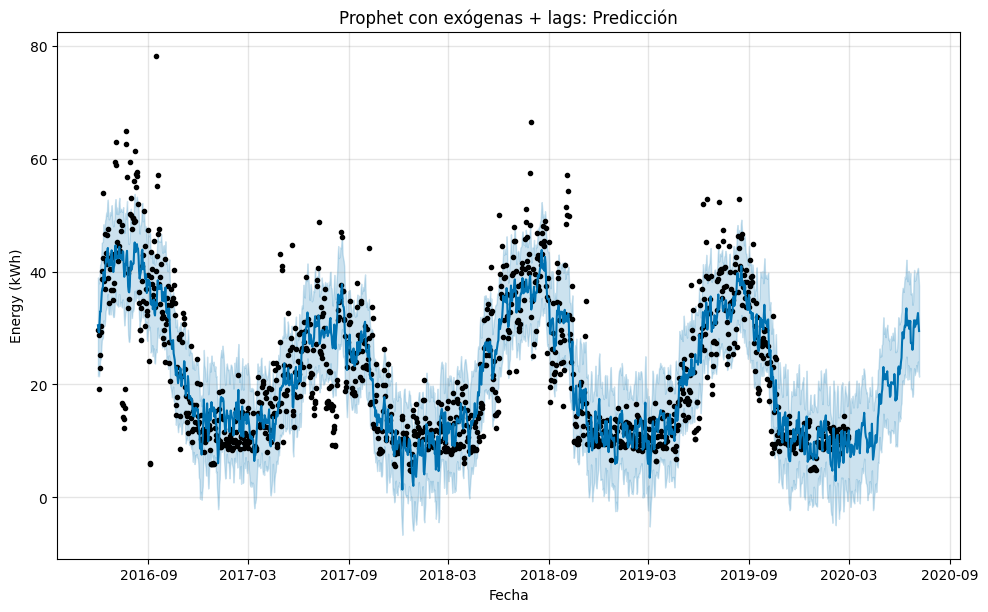

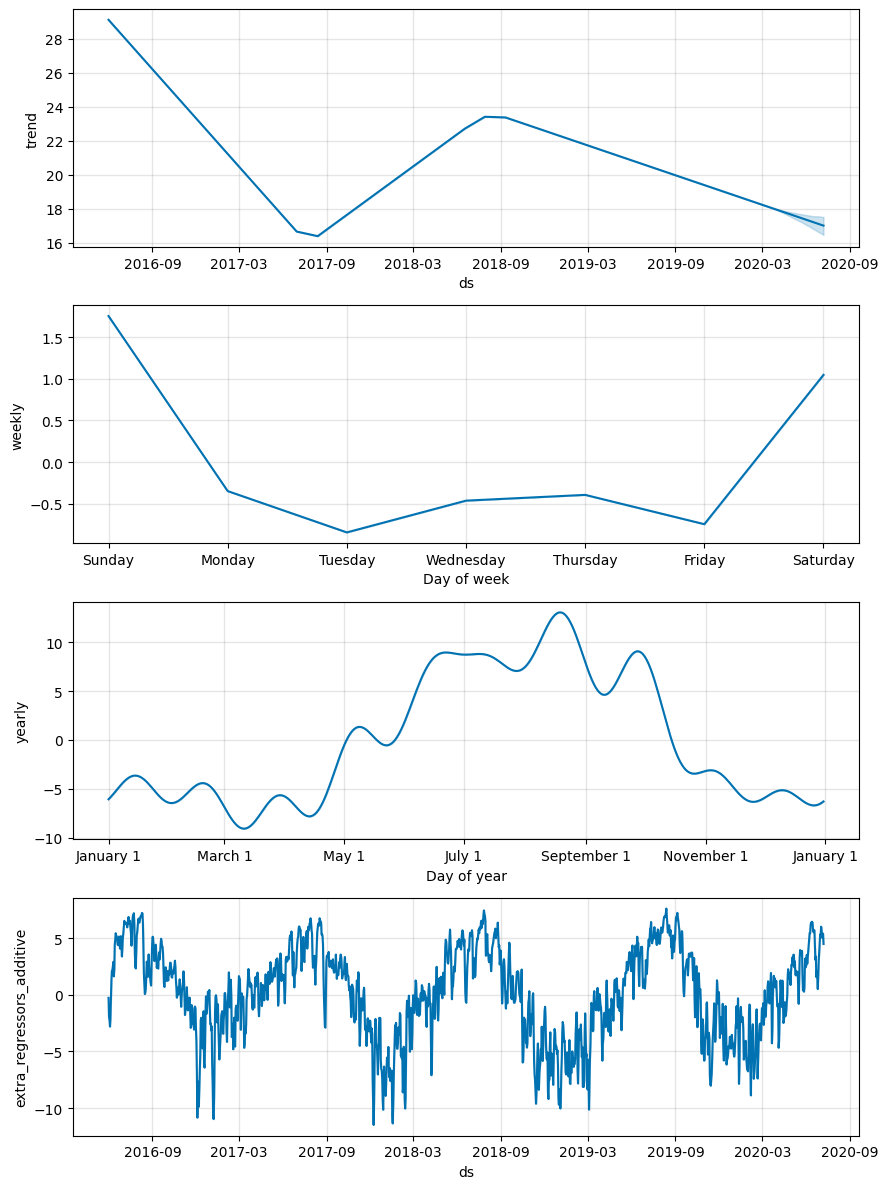

In [76]:
fig = m.plot(forecast)
plt.title("Prophet con exógenas + lags: Predicción")
plt.xlabel("Fecha"); plt.ylabel("Energy (kWh)")
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

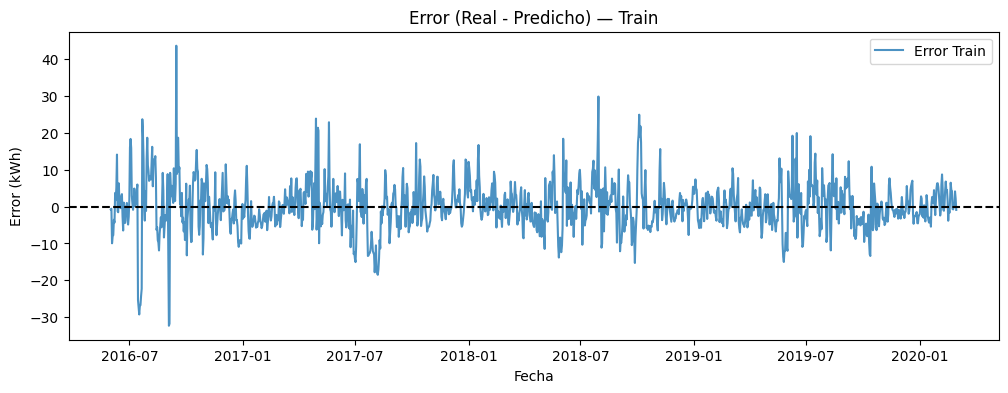

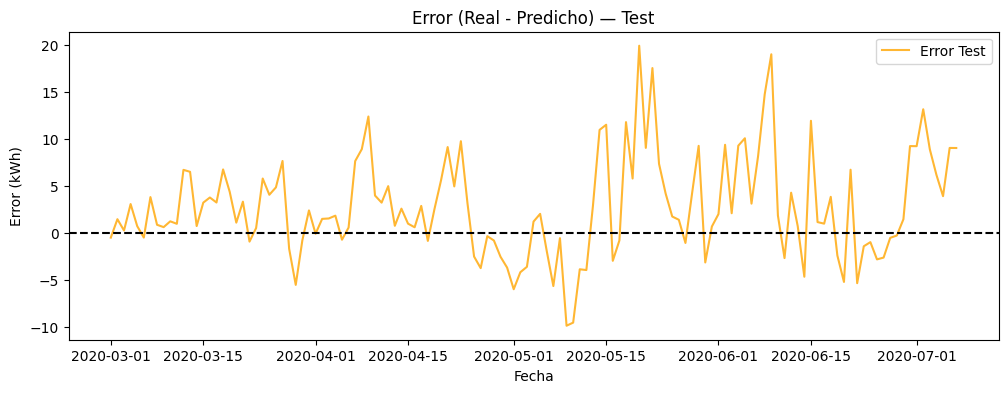

In [77]:
res_train['error'] = res_train['Energy_kWh'] - res_train['yhat']
res_test['error']  = res_test['Energy_kWh'] - res_test['yhat']

plt.figure(figsize=(12,4))
plt.plot(res_train['ds'], res_train['error'], label='Error Train', alpha=0.8)
plt.axhline(0, color='k', linestyle='--')
plt.title("Error (Real - Predicho) — Train")
plt.xlabel("Fecha"); plt.ylabel("Error (kWh)")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(res_test['ds'], res_test['error'], label='Error Test', color='orange', alpha=0.8)
plt.axhline(0, color='k', linestyle='--')
plt.title("Error (Real - Predicho) — Test")
plt.xlabel("Fecha"); plt.ylabel("Error (kWh)")
plt.legend()
plt.show()

In [78]:
print("Resumen de regresores usados:", all_regressors)


Resumen de regresores usados: ['Temp_avg', 'Hum_avg', 'Wind_avg', 'Press_avg', 'Temp_avg_lag1', 'Temp_avg_lag3', 'Hum_avg_lag1', 'Hum_avg_lag2', 'Wind_avg_lag1', 'Press_avg_lag1', 'Press_avg_lag2', 'Press_avg_lag3']


## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


**Respuestas**

En los resultados se puede ver una reducción en el error, el mas bajo de todos modelos, es decir que la optimización si funciono, las variables de estacionalidad son bajos, es decir las variables estacionales representan una baja significancia/patron que se representa en la ventas, mientras que el checkpoint range de 0.95 nos muestra que aprende en un 0.95 de los datos iniciales para detectar tendencia

In [79]:
#NO MODIFICAR ESTA CELDA
import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

Tuning Prophet parameters: 100%|██████████| 54/54 [00:37<00:00,  1.42it/s]


Mejores hiperparámetros encontrados:
{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.95}


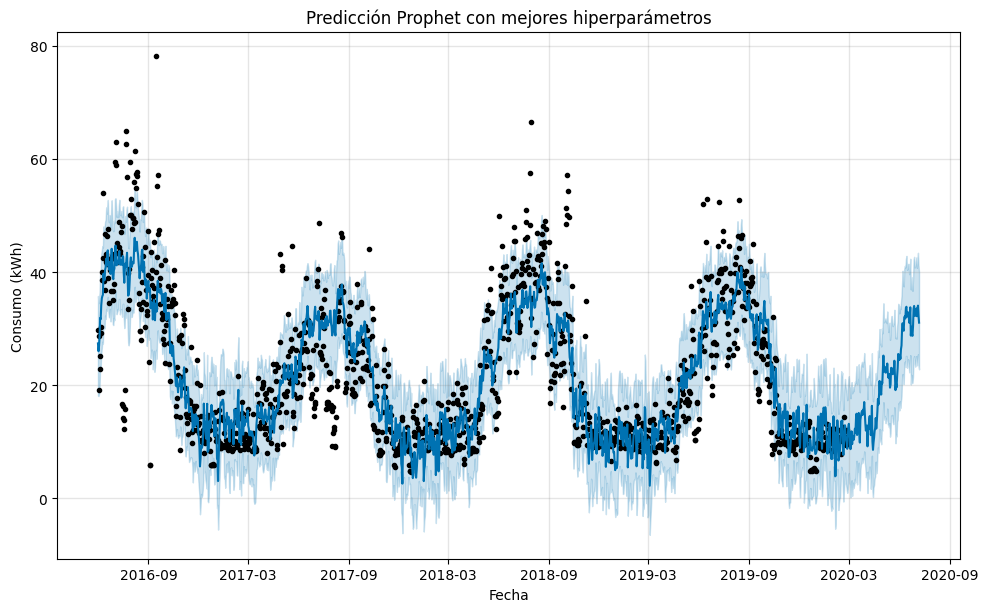

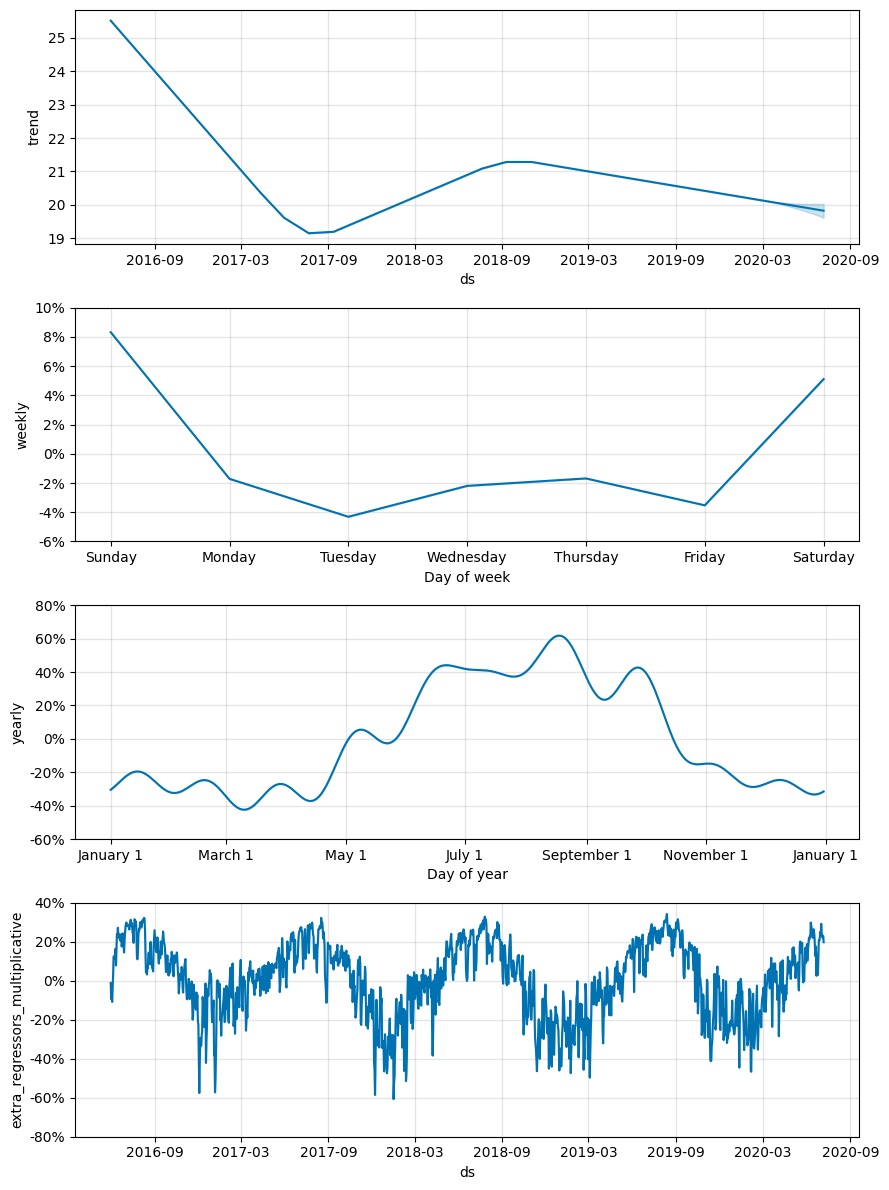

MAE Train: 4.87
MAE Test : 4.05


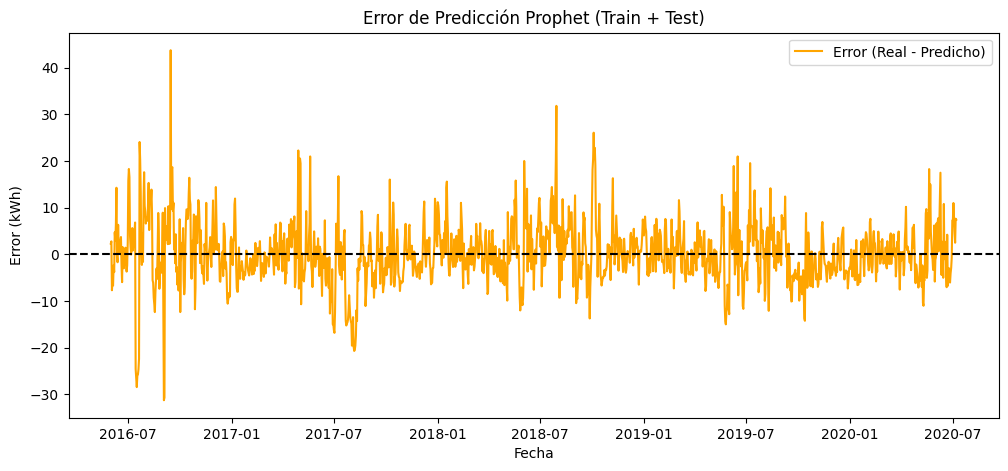

In [ ]:
# Preparar datos Prophet
train_prophet = train_df.rename(columns={'date':'ds', 'Energy_kWh':'y'})
test_prophet  = test_df.rename(columns={'date':'ds', 'Energy_kWh':'y'})
future_df = pd.concat([train_prophet, test_prophet], axis=0)

# Lista de regresores
regresores = ['Temp_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']

# Hiperparámetros
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9, 0.95]
}

# Optimizar Prophet
tuning_results, best_params = optimize_prophet(
    df=train_prophet,
    df_to_pred=test_prophet,
    features=regresores,
    param_grid=param_grid
)

print("Mejores hiperparámetros encontrados:")
print(best_params)

# Crear y entrenar modelo Prophet con los mejores parámetros
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    **best_params
)

# Agregar regresores
for reg in regresores:
    m.add_regressor(reg)

m.fit(train_prophet[['ds', 'y'] + regresores])

# Predicciones
forecast = m.predict(future_df[['ds'] + regresores])

# Graficar predicciones y componentes
fig1 = m.plot(forecast)
plt.title("Predicción Prophet con mejores hiperparámetros")
plt.xlabel("Fecha")
plt.ylabel("Consumo (kWh)")
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

# Calcular MAE
results = future_df.copy()
results['yhat'] = forecast['yhat']

mae_train = mean_absolute_error(
    results.loc[results['ds'] <= fecha_limite, 'y'],
    results.loc[results['ds'] <= fecha_limite, 'yhat']
)

mae_test = mean_absolute_error(
    results.loc[results['ds'] >= pd.to_datetime("2020-03-01"), 'y'],
    results.loc[results['ds'] >= pd.to_datetime("2020-03-01"), 'yhat']
)

print(f"MAE Train: {mae_train:.2f}")
print(f"MAE Test : {mae_test:.2f}")

# Graficar errores
results['error'] = results['y'] - results['yhat']

plt.figure(figsize=(12,5))
plt.plot(results['ds'], results['error'], color='orange', label='Error (Real - Predicho)')
plt.axhline(0, color='black', linestyle='--')
plt.title("Error de Predicción Prophet (Train + Test)")
plt.xlabel("Fecha")
plt.ylabel("Error (kWh)")
plt.legend()
plt.show()


# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [81]:
#!pip install surprise

In [ ]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [ ]:
#CODIGO AQUI

In [ ]:
data_cervezas = pd.read_csv("cervezas.csv")
data_cervezas

,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA
...,...,...,...,...,...
295054,863,45653,4.0,Consecration,American Wild Ale
295055,306,1341,4.0,Keystone Light,Light Lager
295056,8,8917,3.0,Drop Top Amber,American Amber / Red Ale
295057,35,102,3.0,Samuel Adams Octoberfest,Märzen / Oktoberfest


In [ ]:
data_cervezas.isnull().sum()

userId       0
beerId       0
rating       0
beerName     0
beerStyle    0
dtype: int64

In [ ]:
data_cervezas["beerId"].nunique()

3747

In [ ]:
data_cervezas["userId"].nunique()

706

## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

**Respuestas**

1. vemos que hay 706 usuarios en los datos
2. Vemos que hay 3747 productos unicos en los datos
3. Vemos que existen 295059 calificaciones, mas solo existen 3747 pares distintos (userId,beerId), y sumado a esto, podemos observar que cada cerveza fue probada, o calificada por solo una persona, por cual hace sentido que el numero de cerveza coincida con el numero total de pares distintos
4. Si consideramos como total de calificaciones al total de posibles combinaciones que serian 706 * 3747 = 2.645.382, si consideramos que tenemos 3747 datos observados, concluimos que las calificaciones faltantes son 2.641.635
5. 

Podemos observar que cada cerveza solo es puntuada por una persona

In [ ]:
data_cervezas.groupby('beerId')['userId'].nunique()


beerId
5        1
6        1
7        1
9        1
10       1
        ..
74827    1
74904    1
74986    1
75013    1
75086    1
Name: userId, Length: 3747, dtype: int64

Pero vemos que las personas pueden puntuar mas de una cerveza

In [ ]:
data_cervezas.groupby('userId')['beerId'].nunique()

userId
1         1
3        18
4        15
5         3
6         2
         ..
24903     2
25317     1
25923     1
27039     1
27681     1
Name: beerId, Length: 706, dtype: int64

Vemos tambien la cantidad de pares unicos que hay, los cual nos da la cantidad de combinacions de usuarios cerveza que hay

In [ ]:
num_pares_unicos = data_cervezas[['userId', 'beerId']].drop_duplicates().shape[0]
print("Cantidad de pares únicos (userId, beerId):", num_pares_unicos)


Cantidad de pares únicos (userId, beerId): 3747


In [ ]:
#Hacemos una matriz con pandas, que da los valores medios de las puntuaciones, que sirve para visualizar
matriz = data_cervezas.pivot_table(
    index='userId',
    columns='beerId',
    values='rating',
    aggfunc='mean'   
)


print(matriz.head())


print("Dimensiones de la matriz:", matriz.shape)

beerId  5         6         7         9         10        11        14     \
userId                                                                      
1         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
3       3.395  3.765217  3.256849  3.478261       NaN       NaN       NaN   
4         NaN       NaN       NaN       NaN  3.791908       NaN       NaN   
5         NaN       NaN       NaN       NaN       NaN  3.431818       NaN   
6         NaN       NaN       NaN       NaN       NaN       NaN  3.892157   

beerId  15     17     19     ...  74491  74530  74548  74579  74634  74827  \
userId                       ...                                             
1         NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN   
3         NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN   
4         NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN   
5         NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN   

In [ ]:
#Hacemos la matriz con surprise tambien
df_surprise = data_cervezas[['userId', 'beerId', 'rating']]


reader = Reader(rating_scale=(df_surprise['rating'].min(), df_surprise['rating'].max()))


data_surp = Dataset.load_from_df(df_surprise, reader)
#Como comentario no nos hace sentido que sea esto lo que se pide, sino lo anterior, ya que visualizar esto es lo mismo que visualizar df_surprise derechamente
df_surprise.head()

,userId,beerId,rating
0,144,995,3.0
1,63,58695,4.0
2,147,4083,5.0
3,4261,40310,3.0
4,140,1904,5.0


Y a continuacion vemos tambien la puntucacion media de cada persona con las cervezas que puntuaron

In [ ]:
df_avg = df_surprise.groupby(['userId', 'beerId'], as_index=False)['rating'].mean()

df_avg

,userId,beerId,rating
0,1,429,3.834347
1,3,5,3.395000
2,3,6,3.765217
3,3,7,3.256849
4,3,9,3.478261
...,...,...,...
3742,24903,72465,4.289474
3743,25317,68087,3.523810
3744,25923,70745,4.233333
3745,27039,16814,4.639344


## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [ ]:
#CODIGO AQUI

In [ ]:
#data frame de cervezas sera df_cervezas

cols_cerveza = ['beerId', 'beerName', 'beerStyle']  
df_cervezas = data_cervezas[cols_cerveza].drop_duplicates().reset_index(drop=True)

from sklearn.feature_extraction.text import CountVectorizer


vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=10
)


X_bow = vectorizer.fit_transform(df_cervezas['beerStyle'])

df_bow = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out(), index=df_cervezas['beerId'])



from sklearn.metrics.pairwise import cosine_similarity

def top_similares(beer_name, df_cervezas, df_bow, top_n=5):
    beer_id = df_cervezas[df_cervezas['beerName'] == beer_name]['beerId'].values[0]
    

    vec = df_bow.loc[beer_id].values.reshape(1, -1)

    similitudes = cosine_similarity(vec, df_bow)[0]
    

    df_sim = pd.DataFrame({
        'beerId': df_bow.index,
        'similitud': similitudes
    })
    
    df_sim = df_sim[df_sim['beerId'] != beer_id]
    

    top_beers = df_sim.sort_values(by='similitud', ascending=False).head(top_n)
    

    top_beers = top_beers.merge(df_cervezas[['beerId','beerName']], on='beerId')
    
    print(top_beers[['beerName', 'similitud']])

top_similares("Chocolate Porter", df_cervezas, df_bow)

                     beerName  similitud
0         Narragansett Porter        1.0
1          Duck-Rabbit Porter        1.0
2  McNeill's Pullman's Porter        1.0
3             Black Butte XXI        1.0
4             Pipeline Porter        1.0


In [ ]:
# Filtramos ratings de Carl
carl_ratings = data_cervezas[data_cervezas['userId'] == 100]


mejor_cerveza_id = carl_ratings.sort_values(by='rating', ascending=False).iloc[0]['beerId']
mejor_cerveza_name = carl_ratings.sort_values(by='rating', ascending=False).iloc[0]['beerName']

print("Mejor cerveza de Carl:", mejor_cerveza_name)


top_similares(mejor_cerveza_name, df_cervezas, df_bow)

Mejor cerveza de Carl: McNeill's Firehouse Amber Ale
                               beerName  similitud
0                        Tasman Red IPA        1.0
1                    Shark Bite Red Ale        1.0
2                         Ashland Amber        1.0
3         Double Dread Imperial Red Ale        1.0
4  Harpoon Leviathan - Imperial Red Ale        1.0


## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

1. El orden en que se presentan las columnas importa, pues una sera el indice, otra sera las columnas, y otra sera el valor que tendran las celdas de esta nuevo Dataset creado por surprise

In [ ]:
#CODIGO AQUI

In [ ]:
df_surprise = data_cervezas[['userId', 'beerId', 'rating']]


reader = Reader(rating_scale=(df_surprise['rating'].min(), df_surprise['rating'].max()))


data_surp = Dataset.load_from_df(df_surprise, reader)
data_surp

In [ ]:
from surprise.model_selection import train_test_split



trainset, testset = train_test_split(data = data_surp, test_size = 0.3, random_state = 3380)
trainset

In [ ]:
sim_options = {
    'name': 'cosine',       
    'user_based': True      
}

algo_user = KNNBasic(sim_options=sim_options)


algo_user.fit(trainset)


predicciones_user = algo_user.test(testset)
df_predictions = pd.DataFrame(predicciones_user)
df_predictions.drop(columns = ['details'])

Computing the cosine similarity matrix...
Done computing similarity matrix.


,uid,iid,r_ui,est
0,651,52043,3.5,3.807692
1,10099,6260,5.0,3.850000
2,140,37477,4.5,4.112500
3,148,25989,5.0,3.837500
4,1837,5245,4.0,3.966667
...,...,...,...,...
88513,651,6076,4.5,4.250000
88514,143,1352,3.0,3.212500
88515,863,22790,4.5,4.412500
88516,12985,47941,4.0,3.825000


In [ ]:
print("MAE basado en usuarios")
mae(predicciones_user)

MAE:  0.4652


0.46520802143256357

In [ ]:
sim_options_2 = {
    'name': 'cosine',       
    'user_based': False      
}

algo_user_2= KNNBasic(sim_options=sim_options_2)


algo_user_2.fit(trainset)


predicciones_user_2 = algo_user_2.test(testset)
df_predictions_2 = pd.DataFrame(predicciones_user_2)
df_predictions_2.drop(columns = ['details'])

Computing the cosine similarity matrix...
Done computing similarity matrix.


,uid,iid,r_ui,est
0,651,52043,3.5,4.209859
1,10099,6260,5.0,3.850000
2,140,37477,4.5,4.112500
3,148,25989,5.0,3.837500
4,1837,5245,4.0,3.912769
...,...,...,...,...
88513,651,6076,4.5,4.250000
88514,143,1352,3.0,3.212500
88515,863,22790,4.5,4.412500
88516,12985,47941,4.0,3.825000


In [ ]:
print("MAE basado en productos")
mae(predicciones_user_2)

MAE basado en productos
MAE:  0.4652


0.46523121163672004

### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

5. El mejor modelo termina siendo SVD, pues es el que presenta menor MAE entre los 2 estudiados

In [ ]:
#CODIGO AQUI

In [ ]:
model_nmf = NMF(random_state=42)


model_nmf.fit(trainset)


nmf_predictions = model_nmf.test(testset)

df_predictions_nmf = pd.DataFrame(nmf_predictions)
df_predictions_nmf.drop(columns = ['details'])

,uid,iid,r_ui,est
0,651,52043,3.5,3.395304
1,10099,6260,5.0,3.725277
2,140,37477,4.5,4.132993
3,148,25989,5.0,3.718539
4,1837,5245,4.0,3.756853
...,...,...,...,...
88513,651,6076,4.5,3.737876
88514,143,1352,3.0,3.129260
88515,863,22790,4.5,4.206707
88516,12985,47941,4.0,3.747887


In [ ]:
print("MAE modelo NMF")
mae(nmf_predictions)

MAE modelo NMF
MAE:  0.4826


0.48258817545533794

In [ ]:
svd_model = SVD(random_state=42)


svd_model.fit(trainset)


svd_predictions = svd_model.test(testset)

df_predictions_svd = pd.DataFrame(svd_predictions)
df_predictions_svd.drop(columns = ['details'])

,uid,iid,r_ui,est
0,651,52043,3.5,3.829586
1,10099,6260,5.0,3.847089
2,140,37477,4.5,4.106393
3,148,25989,5.0,3.886361
4,1837,5245,4.0,3.950976
...,...,...,...,...
88513,651,6076,4.5,4.169599
88514,143,1352,3.0,3.234625
88515,863,22790,4.5,4.328370
88516,12985,47941,4.0,3.796228


In [ ]:
print("MAE modelo svd")
mae(svd_predictions)

MAE modelo svd
MAE:  0.4627


0.46265158880428425

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [ ]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [ ]:
#Desarrolle su código aquí

In [ ]:
from collections import defaultdict



#Ocuparemos la funcion mostrada en clase, pero adaptaremos para evitar duplicados
def get_top_n(predictions, n=10):
    """Return the top-N recommendation for each user from a set of predictions.

    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.

    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    """

    
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    
    for uid, user_ratings in top_n.items():
        user_ratings = {iid: est for iid, est in user_ratings} #Creamos un diccionario, y asi aseguramamos que no se tenga multiple predicciones de una misma cerveza
        user_ratings = list(user_ratings.items()) #Armamos la lista
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [ ]:
top = get_top_n(svd_predictions)

carl_recommendations = top[100][:3]  # Top 3
print("Top 3 cervezas recomendadas para Carl:", carl_recommendations)

Top 3 cervezas recomendadas para Carl: [(325, 4.038007697004807), (1393, 3.9013124307838805), (1814, 3.755170277292608)]


In [ ]:
import random
random.seed(42)

df_evaluadas  = df_surprise[df_surprise["userId"] == 100]
cervezas_evaluadas = df_evaluadas["beerId"].unique()
cervezas = df_surprise["beerId"].unique()
no_evaluadas = [i for i in cervezas if i not in cervezas_evaluadas]

cervezas_aleatorias = random.sample(no_evaluadas, 5)

for beer in cervezas_aleatorias:
    pred = svd_model.predict(uid=100, iid=beer)
    print(f"Carl - Beer {beer}: Predicted Rating = {pred.est:.2f}")



Carl - Beer 3339: Predicted Rating = 3.83
Carl - Beer 18272: Predicted Rating = 3.89
Carl - Beer 50570: Predicted Rating = 4.00
Carl - Beer 71369: Predicted Rating = 3.75
Carl - Beer 50795: Predicted Rating = 3.69


In [ ]:
precisions, recalls = precision_recall_at_k(svd_predictions)
pre_promedio = np.mean(list(precisions.values()))
rec_promedio = np.mean(list(recalls.values()))
print("Precision promedio = ",pre_promedio)
print("Recall promedio = ",rec_promedio)

Precision promedio =  0.7464437474706596
Recall promedio =  0.3449816670046176


In [ ]:
import plotly.graph_objects as go
import numpy as np

ks = list(range(3, 26))
mean_precisions = []
mean_recalls = []

for k in ks:
    precisions, recalls = precision_recall_at_k(svd_predictions, k=k, threshold=3.5)
    mean_precisions.append(np.mean(list(precisions.values())))
    mean_recalls.append(np.mean(list(recalls.values())))


fig = go.Figure()


fig.add_trace(go.Scatter(
    x=ks, y=mean_precisions,
    mode='lines+markers',
    name='Precisión@k'
))


fig.add_trace(go.Scatter(
    x=ks, y=mean_recalls,
    mode='lines+markers',
    name='Recall@k'
))


fig.update_layout(
    title='Precisión y Recall promedio en función de k',
    xaxis_title='k',
    yaxis_title='Valor promedio',
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0,1]),
    template='plotly_white'
)

fig.show()


In [ ]:
import numpy as np
import plotly.graph_objects as go

# Rango de thresholds
thresholds = np.arange(3.0, 4.6, 0.1)

mean_precisions = []
mean_recalls = []

for t in thresholds:
    precisions, recalls = precision_recall_at_k(svd_predictions, k=10, threshold=t)
    mean_precisions.append(np.mean(list(precisions.values())))
    mean_recalls.append(np.mean(list(recalls.values())))


fig = go.Figure()


fig.add_trace(go.Scatter(
    x=thresholds, y=mean_precisions,
    mode='lines+markers',
    name='Precisión@k'
))


fig.add_trace(go.Scatter(
    x=thresholds, y=mean_recalls,
    mode='lines+markers',
    name='Recall@k'
))


fig.update_layout(
    title='Precisión y Recall promedio en función del Threshold',
    xaxis_title='Threshold',
    yaxis_title='Valor promedio',
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0, 1]),
    template='plotly_white'
)

fig.show()


In [ ]:
# Copiamos la matriz original, pues en esta rellenaremos los valores con Nan
matriz_completa = matriz.copy()


for user in matriz_completa.index:
    for beer in matriz_completa.columns:
        if pd.isna(matriz_completa.loc[user, beer]):
            # Predecimos el rating usando el mejor modelo entrenado
            pred = svd_model.predict(user, beer).est
            matriz_completa.loc[user, beer] = pred


print(matriz_completa.head())

beerId     5         6         7         9         10        11        14     \
userId                                                                         
1       3.591442  3.959634  3.729856  3.731691  3.692821  3.761684  3.934921   
3       3.395000  3.765217  3.256849  3.478261  3.429106  3.462113  3.653222   
4       3.799911  4.071680  3.763443  3.915116  3.791908  3.824508  3.991857   
5       3.573387  3.933819  3.672167  3.771343  3.663227  3.431818  3.863557   
6       3.893307  3.792050  3.674871  3.801671  3.820261  3.844489  3.892157   

beerId     15        17        19     ...     74491     74530     74548  \
userId                                ...                                 
1       3.862869  3.650501  3.933334  ...  3.765036  4.148201  3.958891   
3       3.590191  3.436246  3.685994  ...  3.510795  3.847932  3.750486   
4       3.987118  3.811082  4.064121  ...  3.908127  4.221662  4.104232   
5       3.822949  3.729848  3.978187  ...  3.738210  4.143918  4

**Respuesta:**

3. Alcanzando una precision del 74%, y un recall del 34% aproximadamente, vemos que, si bien no son valores extremadamente altos, y el recall es de menos del 50%, vemos que igual, de los valores predichos, 3 de cada 4 se predice un rating similar, por lo que se espera poder hacer buenas recomendaciones, y poder elegir relativamente seguro, buenas cervezas para cada persona, mas cuando existe una gran cantidad de cervezas que no fueron correcatmente evaluadas segun la prediccion

4. Vemos que al aumentar el k, la presicion no cambia, pero si se logra un aumento del recall, el cual es creciente respecto al k

5. Respecto al treshold, vemos que al aumentarlo, tanto la presicion como recall comienzan a disminuir, lo cual hace sentido, pues se hac eun poco mas laxo los limites cercanos al rating real que se tiene.

In [ ]:
#Tambien lo hacemos de acuerdo a lo visto en clases

full_trainset = data_surp.build_full_trainset() # primero separamos los (usuario, producto) con ratings
missing_ratings = full_trainset.build_anti_testset() # luego obtenemos los valores sin ratings
predicciones_faltantes_clases = svd_model.test(missing_ratings) # predecimos para los valores faltantes

In [ ]:
df_predictions_svd_completa = pd.DataFrame(predicciones_faltantes_clases)
df_predictions_svd_completa.drop(columns = ['details'])

,uid,iid,r_ui,est
0,144,58695,3.860367,3.624446
1,144,4083,3.860367,3.925454
2,144,40310,3.860367,3.618707
3,144,1904,3.860367,3.973240
4,144,409,3.860367,3.706099
...,...,...,...,...
2641630,1503,4957,3.860367,3.786902
2641631,1503,47589,3.860367,3.877914
2641632,1503,62792,3.860367,3.409886
2641633,1503,18432,3.860367,3.622063


In [ ]:
#Ahora llenamos toda la matirz hecha con pivot table en 2.1, con los valores de la prediccion anterior


df_preds = pd.DataFrame([(pred.uid, pred.iid, pred.est) for pred in predicciones_faltantes_clases],
                        columns=['userId', 'beerId', 'pred_rating'])


pred_matrix = df_preds.pivot(index='userId', columns='beerId', values='pred_rating')


matriz_completa_filled = matriz_completa.copy()
matriz_completa_filled.fillna(pred_matrix, inplace=True)
matriz_completa_filled.head()


beerId,5,6,7,9,10,11,14,15,17,19,...,74491,74530,74548,74579,74634,74827,74904,74986,75013,75086
userId,,,,,,,,,,,,,,,,,,,,,
1,3.591442,3.959634,3.729856,3.731691,3.692821,3.761684,3.934921,3.862869,3.650501,3.933334,...,3.765036,4.148201,3.958891,3.999550,3.830023,3.983493,3.999543,4.096387,3.997981,3.665192
3,3.395000,3.765217,3.256849,3.478261,3.429106,3.462113,3.653222,3.590191,3.436246,3.685994,...,3.510795,3.847932,3.750486,3.786184,3.564451,3.765954,3.791162,3.891781,3.785386,3.467089
4,3.799911,4.071680,3.763443,3.915116,3.791908,3.824508,3.991857,3.987118,3.811082,4.064121,...,3.908127,4.221662,4.104232,4.128301,3.902714,4.130911,4.136546,4.254353,4.147209,3.807185
5,3.573387,3.933819,3.672167,3.771343,3.663227,3.431818,3.863557,3.822949,3.729848,3.978187,...,3.738210,4.143918,4.065264,3.946777,3.754095,3.817598,3.924166,4.018215,4.208863,3.564689
6,3.893307,3.792050,3.674871,3.801671,3.820261,3.844489,3.892157,3.962512,3.599677,3.944453,...,3.745535,4.007054,4.133913,4.143259,3.889786,3.979055,3.985451,4.342954,3.938917,3.676177


# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
